# Goal-directed molecule generation bake-off

**Classical SELFIES-GRU vs hybrid 6-qubit QCBM** on public drug seeds.

This notebook is the full protocol: same seeds, same attempt budget, same Morgan Tanimoto filter, same QED objective. It is a *portfolio experiment on a simulator*, not a claim that quantum computers design drugs.

**What to look for**

1. Both generators run end-to-end and emit valid molecules.
2. Kept analogs (Tanimoto ≥ 0.40 to the seed) are ranked by ΔQED.
3. The quantum piece is a real PennyLane circuit (6-qubit `Rot` + ring `CNOT` ansatz on `default.qubit`) whose Born probabilities steer analog decoding.


## 0. Setup

Imports, reproducible RNG, and paths that work whether the kernel cwd is the repo root or `notebooks/`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
sys.path.insert(0, str(ROOT))

from src.config import (
    GRU_EPOCHS,
    N_ATTEMPTS,
    N_QUBITS,
    QCBM_LAYERS,
    QCBM_STEPS,
    RANDOM_SEED,
    SIMILARITY_THRESHOLD,
)
from src.data import load_reference, load_seeds
from src.hybrid_quantum import make_qcbm, random_params
from src.metrics import top_kept
from src.protocol import neighborhood_preview, run_bakeoff
from src import viz

viz.setup_style()
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 80)

print("repo", ROOT)
print("attempts / method / seed:", N_ATTEMPTS)
print("Tanimoto keep threshold:", SIMILARITY_THRESHOLD)
print("GRU epochs:", GRU_EPOCHS, "| QCBM steps:", QCBM_STEPS, "| qubits:", N_QUBITS)
print("PennyLane", qml.__version__)


repo /workspace
attempts / method / seed: 160
Tanimoto keep threshold: 0.4
GRU epochs: 18 | QCBM steps: 70 | qubits: 6
PennyLane 0.45.1


## 1. Seeds and public reference corpus

Six widely documented small-molecule drugs, taken from the public [`HIPS/molecule-autoencoder`](https://github.com/HIPS/molecule-autoencoder) `all_drugs.smi` list (see `data/README.md`). They span **low → high QED** so the task is not “everything is already maxed out.”

The reference set is the same list after drug-like filters (~1k organic, single-fragment structures). It is the GRU training corpus **and** the novelty blacklist.


,name,smiles,QED,SA,heavy_atoms
0,isoniazid,NNC(=O)c1ccncc1,0.317,1.904,10
1,aspirin,CC(=O)Oc1ccccc1C(=O)O,0.550,1.580,13
2,caffeine,Cn1c(=O)c2c(ncn2C)n(C)c1=O,0.538,2.298,14
3,acetaminophen,CC(=O)Nc1ccc(O)cc1,0.595,1.407,11
4,sulfanilamide,Nc1ccc(S(N)(=O)=O)cc1,0.581,1.694,11
5,ibuprofen,CC(C)Cc1ccc(C(C)C(=O)O)cc1,0.822,2.192,15


reference molecules: 1098


,seed,qed,sa,top_k,max_sim,mean_sim
0,isoniazid,0.317,1.904,40,0.353,0.236
1,aspirin,0.550,1.580,40,0.594,0.279
2,caffeine,0.538,2.298,40,0.537,0.201
3,acetaminophen,0.595,1.407,40,0.400,0.243
4,sulfanilamide,0.581,1.694,40,0.650,0.289
5,ibuprofen,0.822,2.192,40,0.462,0.304


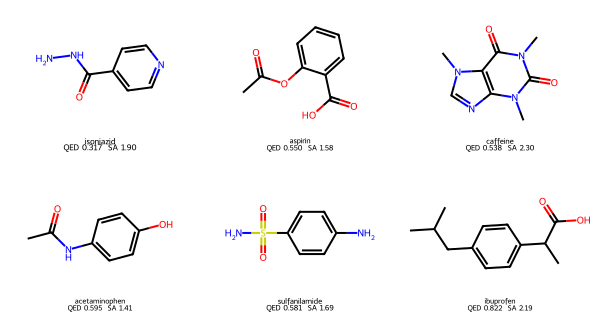

In [2]:
seeds = load_seeds()
library = load_reference()
seed_df = pd.DataFrame(
    {
        "name": [s.name for s in seeds],
        "smiles": [s.smiles for s in seeds],
        "QED": [s.qed for s in seeds],
        "SA": [s.sa for s in seeds],
        "heavy_atoms": [s.mol.GetNumHeavyAtoms() for s in seeds],
    }
)
display(seed_df)
print(f"reference molecules: {len(library)}")
display(neighborhood_preview(seeds, library))
path = viz.save_seed_grid(seeds)
display(Image.open(path))


## 2. Fair protocol

For **each seed**, **each method** does the following with a locked random seed:

| Step | Rule |
| --- | --- |
| Propose | exactly `N_ATTEMPTS` strings (160) |
| Valid | RDKit parse + sanitize |
| Unique | canonical SMILES |
| Novel | not in the public reference set |
| Similar | Morgan r=2 Tanimoto ≥ 0.40 vs seed, and not identical to the seed |
| Score | QED; report ΔQED and Ertl SA |

**Classical path:** pretrain a SELFIES GRU on the corpus, fine-tune on the seed neighborhood (+ a small enumerated analog cloud), sample with seed-prefix completion.

**Hybrid path:** fit a 6-bit PCA fingerprint encoder on the corpus, train a 6-qubit QCBM on the QED-weighted neighborhood distribution, sample bitstrings, decode with bitstring-conditioned analog mutations of the seed / nearest neighbors.

The protocol equalizes **budget and filters**. It does not pretend the two inductive biases are the same: the GRU is a chemical language model; the QCBM is a local latent sampler on a simulator.


## 3. The quantum circuit (6 qubits)

`Rot` on each wire plus a ring of `CNOT`s, repeated for 4 layers (the usual strongly-entangling pattern). The Born machine output is a probability table over \(2^6 = 64\) bitstrings. That is small enough for an exact statevector simulator and large enough to be a real variational circuit, not a coin flip in disguise.


0: ──Rot(0.09,-0.31,0.23)──╭●─────────────╭X──Rot(0.26,-0.01,-0.06)─╭●─────────────╭X──Rot(-0.03,-0.25,-0.25)─╭●─── ···
1: ──Rot(0.28,-0.59,-0.39)─╰X─╭●──────────│───Rot(-0.20,0.37,-0.05)─╰X─╭●──────────│───Rot(0.20,0.22,0.16)────╰X─╭● ···
2: ──Rot(0.04,-0.09,-0.01)────╰X─╭●───────│───Rot(-0.13,-0.11,0.16)────╰X─╭●───────│───Rot(-0.20,0.07,0.04)──────╰X ···
3: ──Rot(-0.26,0.26,0.23)────────╰X─╭●────│───Rot(0.11,0.12,0.13)─────────╰X─╭●────│───Rot(0.07,0.26,0.07)───────── ···
4: ──Rot(0.02,0.34,0.14)────────────╰X─╭●─│───Rot(0.64,-0.12,-0.15)──────────╰X─╭●─│───Rot(0.20,0.02,0.09)───────── ···
5: ──Rot(-0.26,0.11,-0.29)─────────────╰X─╰●──Rot(-0.24,0.18,0.34)──────────────╰X─╰●──Rot(0.19,-0.44,-0.10)─────── ···

0: ··· ──────────╭X──Rot(-0.14,-0.19,-0.08)─╭●─────────────╭X─┤ ╭Probs
1: ··· ──────────│───Rot(0.45,-0.26,0.29)───╰X─╭●──────────│──┤ ├Probs
2: ··· ─╭●───────│───Rot(-0.50,-0.10,0.05)─────╰X─╭●───────│──┤ ├Probs
3: ··· ─╰X─╭●────│───Rot(0.18,0.21,0.24)──────────╰X─╭●────│──┤ ├P

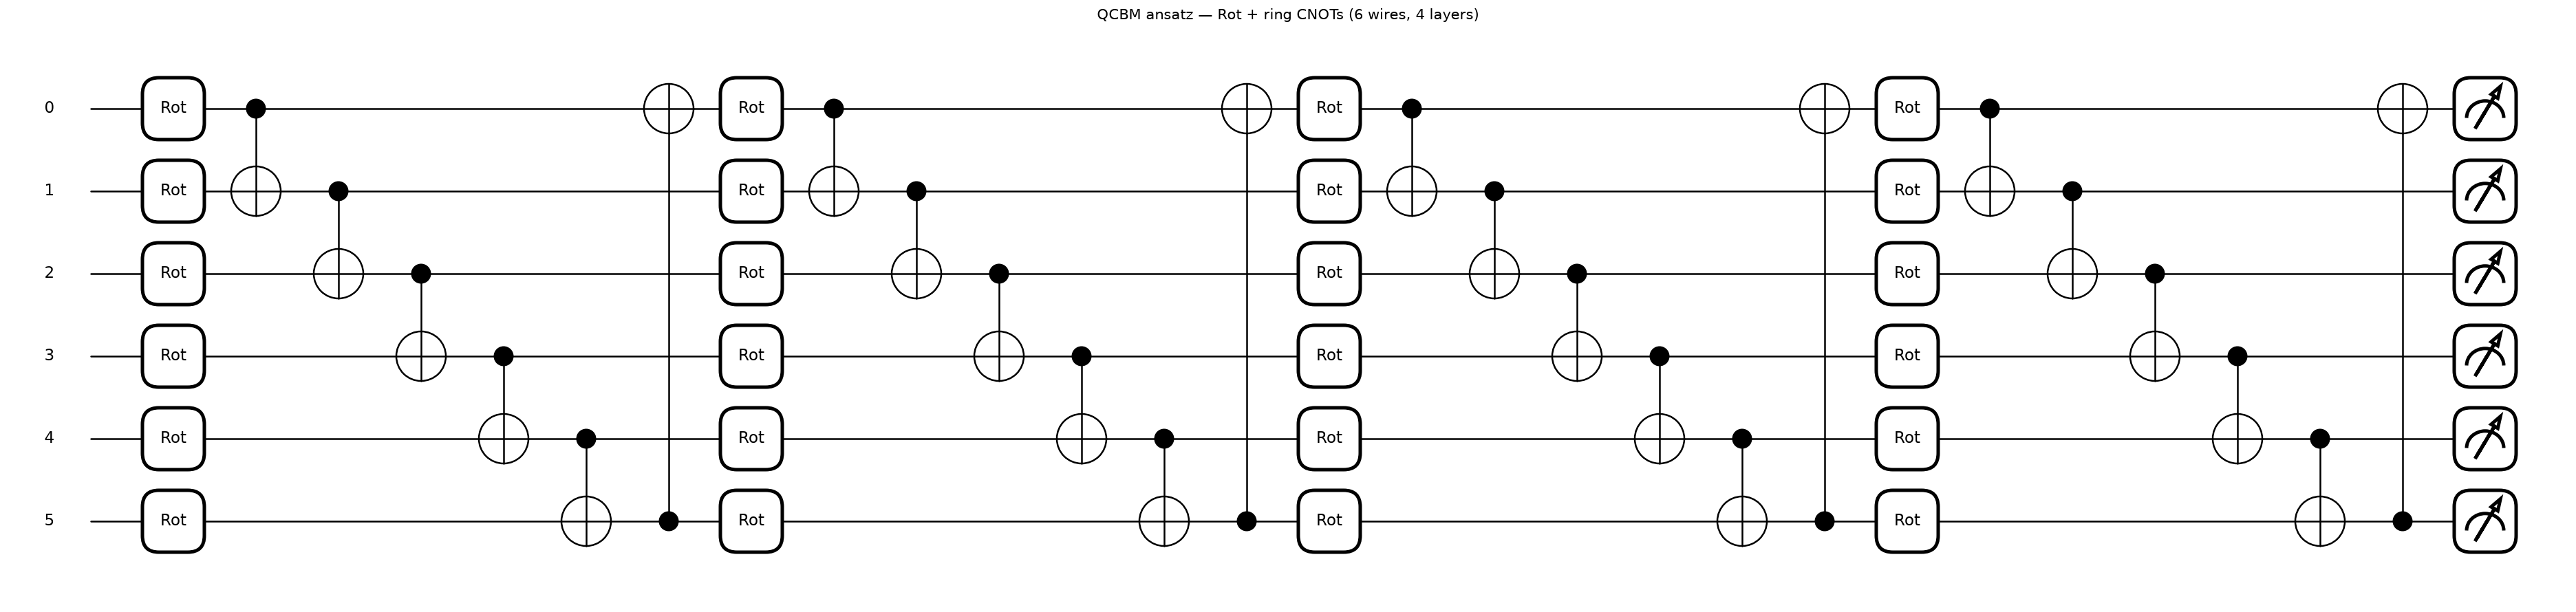

In [3]:
circuit = make_qcbm(n_qubits=N_QUBITS, n_layers=QCBM_LAYERS)
params = random_params(n_qubits=N_QUBITS, n_layers=QCBM_LAYERS, seed=RANDOM_SEED)
print(qml.draw(circuit, max_length=120)(params)[:1800])
print("parameter tensor", np.shape(params), "n_params", int(np.size(params)))

fig, ax = qml.draw_mpl(circuit, decimals=None)(params)
ax.set_title("QCBM ansatz — Rot + ring CNOTs (6 wires, 4 layers)")
viz.savefig(fig, "qcbm_circuit.png")
display(fig)
plt.close(fig)


## 4. Run the bake-off

This cell trains the GRU, fits every per-seed QCBM, generates both candidate pools, and writes `figures/metrics_*.csv`. On a CPU VM it should finish in a few minutes.


In [4]:
bundle = run_bakeoff(
    n_attempts=N_ATTEMPTS,
    sim_threshold=SIMILARITY_THRESHOLD,
    seed=RANDOM_SEED,
)
metrics = bundle["metrics"]
agg = bundle["aggregate"]
results = bundle["results"]
print("GRU pretrain NLL by epoch:", [round(x, 3) for x in bundle["trainer"].losses])
display(metrics)
display(agg)


GRU pretrain NLL by epoch: [2.408, 1.878, 1.712, 1.626, 1.565, 1.522, 1.488, 1.46, 1.437, 1.414, 1.395, 1.379, 1.363, 1.351, 1.338, 1.327, 1.313, 1.305]


,seed,method,seed_qed,attempted,n_valid,validity,uniqueness,novelty,n_kept,mean_tanimoto_kept,max_tanimoto_kept,mean_qed_kept,mean_delta_qed,max_delta_qed,frac_improved,mean_sa_kept
0,isoniazid,classical_gru,0.317,160,160,1.0,0.581,0.575,34,0.496,0.600,0.313,-0.004,0.133,0.353,2.163
1,isoniazid,hybrid_qcbm,0.317,160,160,1.0,0.388,0.388,8,0.548,0.607,0.308,-0.008,0.020,0.500,2.200
2,aspirin,classical_gru,0.550,160,160,1.0,0.681,0.675,52,0.549,0.793,0.566,0.016,0.270,0.673,1.985
3,aspirin,hybrid_qcbm,0.550,160,160,1.0,0.438,0.431,15,0.564,0.690,0.592,0.042,0.136,0.600,1.894
4,caffeine,classical_gru,0.538,160,160,1.0,0.819,0.812,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,caffeine,hybrid_qcbm,0.538,160,160,1.0,0.338,0.331,15,0.550,0.667,0.623,0.085,0.262,0.867,2.645
6,acetaminophen,classical_gru,0.595,160,160,1.0,0.531,0.525,33,0.517,0.667,0.658,0.063,0.230,0.788,1.769
7,acetaminophen,hybrid_qcbm,0.595,160,160,1.0,0.350,0.350,9,0.540,0.593,0.572,-0.023,0.128,0.556,1.733
8,sulfanilamide,classical_gru,0.581,160,160,1.0,0.625,0.619,8,0.472,0.542,0.579,-0.001,0.098,0.625,2.119
9,sulfanilamide,hybrid_qcbm,0.581,160,160,1.0,0.287,0.275,11,0.463,0.500,0.585,0.004,0.207,0.636,2.134


,method,validity,uniqueness,novelty,n_kept,mean_tanimoto_kept,mean_delta_qed,max_delta_qed,frac_improved,mean_sa_kept
0,classical_gru,1.0,0.617,0.610,22.167,0.518,0.009,0.156,0.588,2.133
1,hybrid_qcbm,1.0,0.356,0.352,11.333,0.545,0.016,0.131,0.626,2.183


## 5. Training curves

Left: chemical language model. Right: quantum latent model. Both should descend; neither is trained to exhaustion on purpose — the budget class is “notebook on a laptop.”


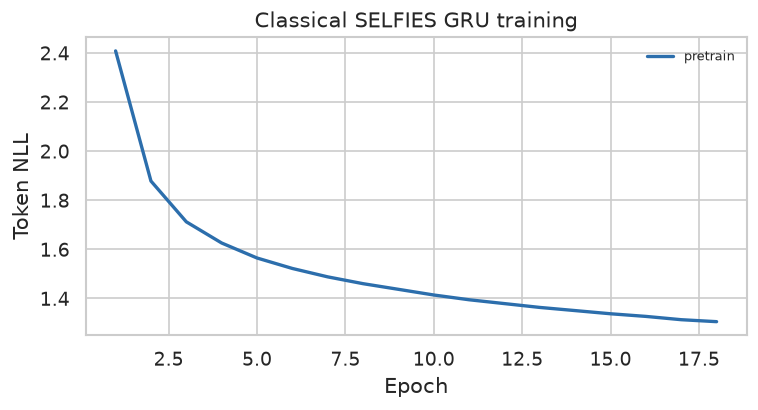

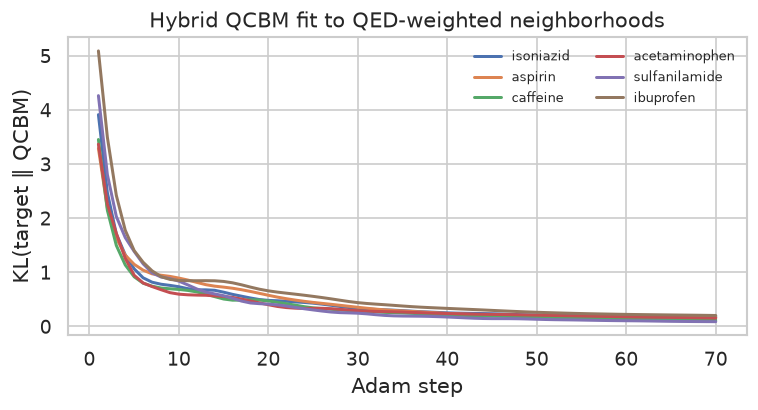

In [5]:
fig = viz.plot_gru_loss(bundle["trainer"].losses, extra=None)
viz.savefig(fig, "gru_pretrain_loss.png")
display(fig)
plt.close(fig)

fig = viz.plot_qcbm_losses(bundle["qcbm_losses"])
viz.savefig(fig, "qcbm_kl_loss.png")
display(fig)
plt.close(fig)


## 6. Head-to-head metrics

Validity / uniqueness / novelty are computed on the raw attempt budget. ΔQED and Tanimoto are computed on the **kept** set (valid, unique, similar, not the seed). Empty keep-sets show up as NaN — that is a real outcome, not a plotting bug.


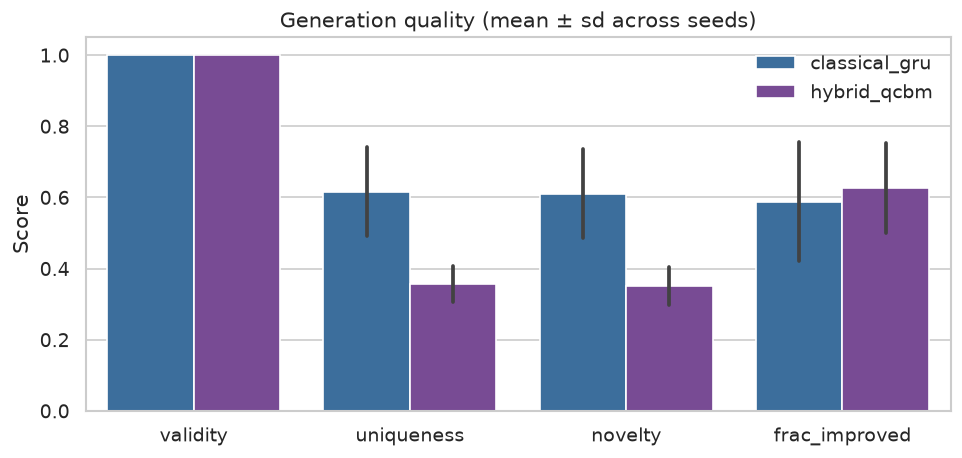

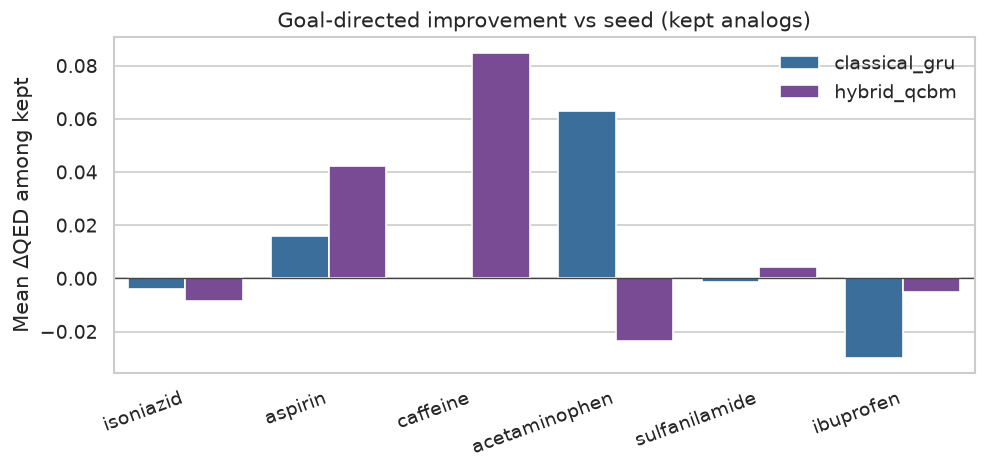

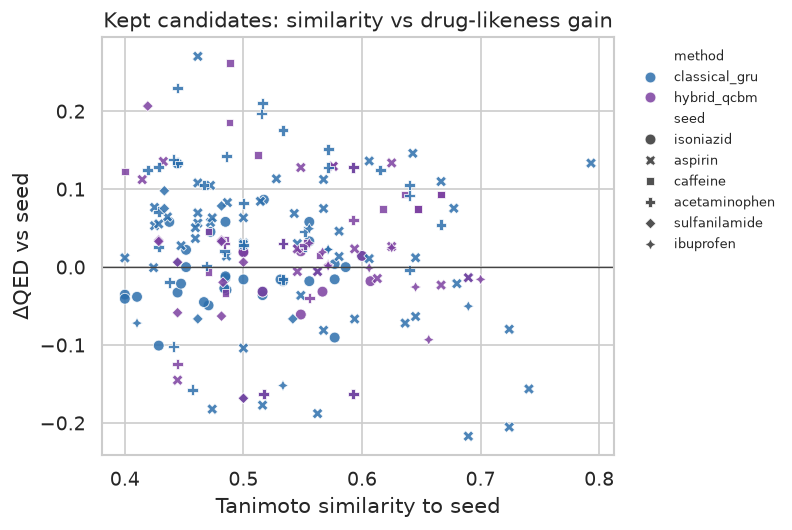

In [6]:
fig = viz.plot_metric_bars(metrics)
viz.savefig(fig, "quality_bars.png")
display(fig)
plt.close(fig)

fig = viz.plot_delta_qed(metrics)
viz.savefig(fig, "delta_qed_by_seed.png")
display(fig)
plt.close(fig)

fig = viz.plot_scatter(results)
viz.savefig(fig, "similarity_vs_delta_qed.png")
display(fig)
plt.close(fig)


## 7. Molecule grids — seed vs top kept analogs

Each panel is stacked: **seed** (top), **top-3 classical by ΔQED**, **top-3 hybrid by ΔQED**. If a method has no analog with Tanimoto ≥ 0.40, the row says so instead of inventing a structure.


isoniazid classical kept 34 hybrid kept 8


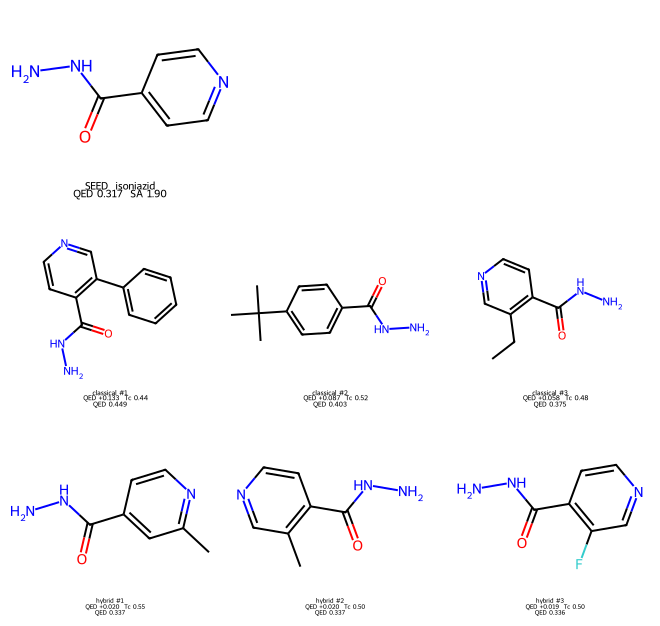

aspirin classical kept 52 hybrid kept 15


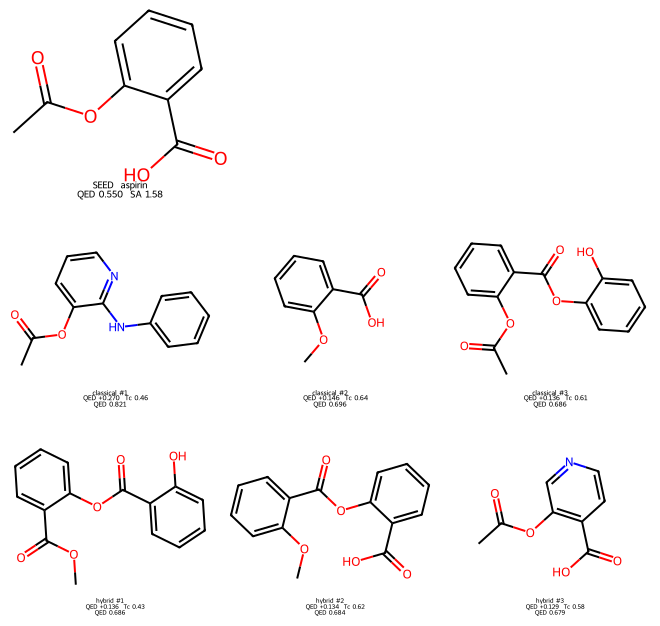

caffeine classical kept 0 hybrid kept 15


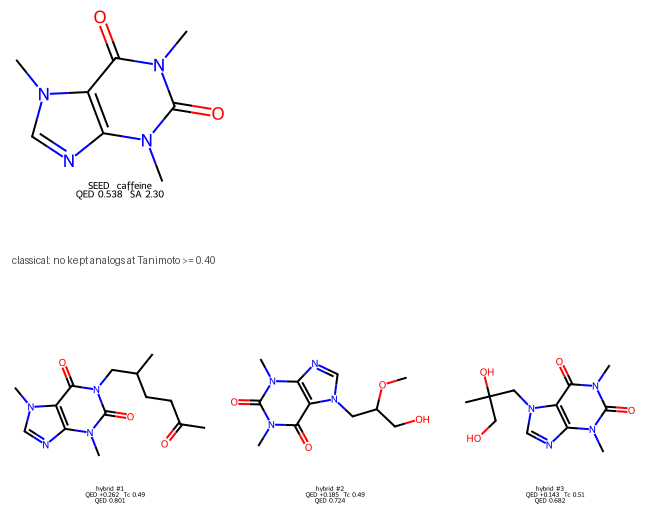

acetaminophen classical kept 33 hybrid kept 9


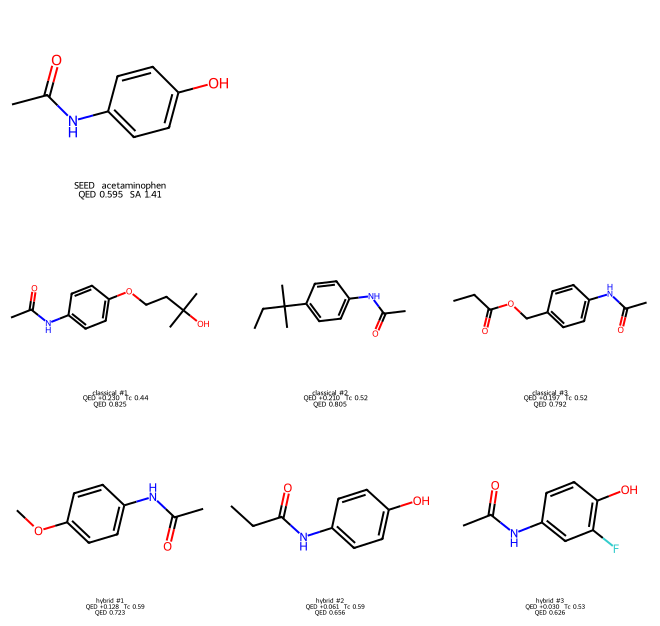

sulfanilamide classical kept 8 hybrid kept 11


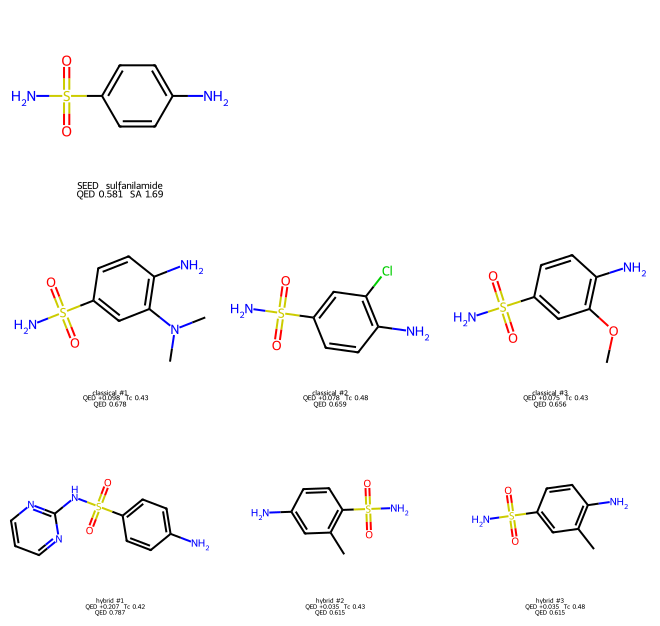

ibuprofen classical kept 6 hybrid kept 10


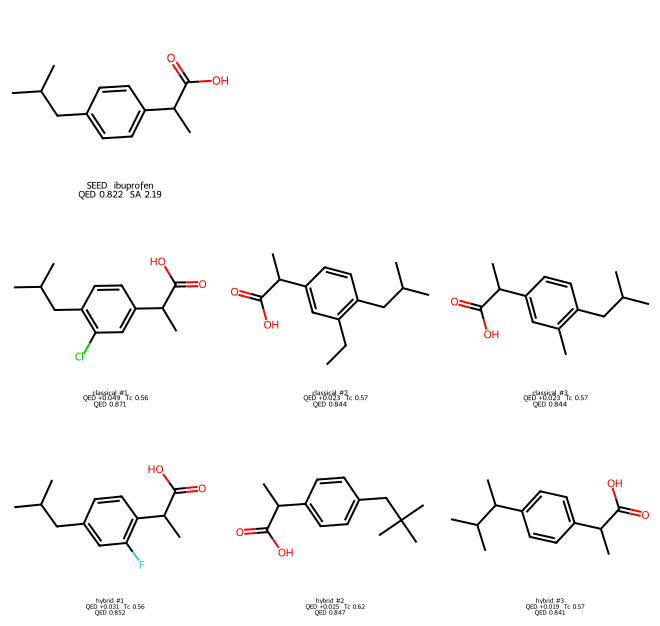

In [7]:
from collections import defaultdict

by_seed = defaultdict(dict)
for res in results:
    by_seed[res.seed_name][res.method] = res

for seed in bundle["seeds"]:
    classical = by_seed[seed.name]["classical_gru"]
    hybrid = by_seed[seed.name]["hybrid_qcbm"]
    img = viz.molecule_grid(seed, classical, hybrid, k=3)
    out = ROOT / "figures" / f"grid_{seed.name}.png"
    img.save(out)
    print(seed.name, "classical kept", len(classical.kept_cands), "hybrid kept", len(hybrid.kept_cands))
    display(img)


## 8. Top improved analog per method

A compact table for the README / portfolio caption. SMILES are canonical RDKit strings.


In [8]:
rows = []
for seed in bundle["seeds"]:
    for method in ("classical_gru", "hybrid_qcbm"):
        tops = top_kept(by_seed[seed.name][method], k=1)
        if not tops:
            rows.append({"seed": seed.name, "method": method, "smiles": None, "delta_qed": np.nan, "tanimoto": np.nan, "qed": np.nan, "sa": np.nan})
            continue
        c = tops[0]
        rows.append(
            {
                "seed": seed.name,
                "method": method,
                "smiles": c.smiles,
                "delta_qed": c.delta_qed,
                "tanimoto": c.tanimoto,
                "qed": c.qed,
                "sa": c.sa,
            }
        )
top_df = pd.DataFrame(rows)
top_df.to_csv(ROOT / "figures" / "top_analog_per_method.csv", index=False)
display(top_df)


,seed,method,smiles,delta_qed,tanimoto,qed,sa
0,isoniazid,classical_gru,NNC(=O)c1ccncc1-c1ccccc1,0.133,0.444,0.449,1.875
1,isoniazid,hybrid_qcbm,Cc1cc(C(=O)NN)ccn1,0.020,0.548,0.337,2.094
2,aspirin,classical_gru,CC(=O)Oc1cccnc1Nc1ccccc1,0.270,0.462,0.821,1.839
3,aspirin,hybrid_qcbm,COC(=O)c1ccccc1OC(=O)c1ccccc1O,0.136,0.432,0.686,1.726
4,caffeine,classical_gru,NaN,NaN,NaN,NaN,NaN
5,caffeine,hybrid_qcbm,CC(=O)CCC(C)Cn1c(=O)c2c(ncn2C)n(C)c1=O,0.262,0.489,0.801,3.060
6,acetaminophen,classical_gru,CC(=O)Nc1ccc(OCCC(C)(C)O)cc1,0.230,0.444,0.825,1.835
7,acetaminophen,hybrid_qcbm,COc1ccc(NC(C)=O)cc1,0.128,0.593,0.723,1.219
8,sulfanilamide,classical_gru,CN(C)c1cc(S(N)(=O)=O)ccc1N,0.098,0.433,0.678,2.226
9,sulfanilamide,hybrid_qcbm,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,0.207,0.419,0.787,1.953


## 9. How to read the result (and how not to)

**Legitimate conclusions**

- A 6-qubit Born machine can be wired into a *goal-directed analog loop* with the same filters as a neural language model.
- On this public, small-scale protocol you can compare validity, locality (Tanimoto), and ΔQED without moving the goalposts.
- SELFIES makes the classical generator chemically valid, so the bake-off is about **neighborhood control and property gain**, not SMILES parentheses.

**Not legitimate conclusions**

- Quantum advantage, drug discovery, or “QCBM beat Big Pharma.”
- That QED-improved analogs would be better medicines (they often would not).
- That 6 simulator qubits extend to 50-qubit chemistry on hardware.

The hybrid decoder is *local by construction*; the GRU is local only insofar as prefix locking and fine-tuning work. If the GRU keep-set is smaller, that is a bias difference the protocol is designed to expose, not hide.


## 10. Re-run

```bash
pip install -r requirements.txt
jupyter notebook notebooks/goal_directed_mol_gen_bakeoff.ipynb
```

Pinned stack: RDKit, PyTorch (CPU is enough), PennyLane `default.qubit`, SELFIES, scikit-learn PCA, matplotlib. No proprietary data, no QPU credentials.
